In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("./loan_default_realistic.csv")

#### 1. Understanding the dataset

In [4]:
df.head()

,age,annual_income,loan_amount,credit_score,loan_tenure_years,existing_loans,employment_type,education_level,marital_status,property_owned,loan_purpose,default
0,50.580257,3.305169e+05,NaN,599.115566,7.682099,NaN,Self-Employed,PhD,NaN,No,Home,No
1,42.475450,1.399313e+06,7.405586e+05,784.022640,NaN,1.322204,Salaried,Diploma,Divorced,Yes,Personal,Yes
2,57.321788,5.759531e+05,4.686859e+05,448.876010,29.579995,NaN,Salaried,PhD,NaN,Yes,Personal,Yes
3,NaN,NaN,1.052662e+06,733.207406,13.870311,4.415269,Self-Employed,Diploma,Married,Yes,NaN,NaN
4,56.554198,NaN,3.833395e+05,302.874446,29.993313,4.245685,NaN,Diploma,Married,No,Car,No


In [5]:
df.shape

(1400, 12)

In [6]:
df.columns

Index(['age', 'annual_income', 'loan_amount', 'credit_score',
       'loan_tenure_years', 'existing_loans', 'employment_type',
       'education_level', 'marital_status', 'property_owned', 'loan_purpose',
       'default'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                931 non-null    float64
 1   annual_income      1008 non-null   float64
 2   loan_amount        1140 non-null   float64
 3   credit_score       1140 non-null   float64
 4   loan_tenure_years  1191 non-null   float64
 5   existing_loans     1072 non-null   float64
 6   employment_type    1195 non-null   object 
 7   education_level    1000 non-null   object 
 8   marital_status     1132 non-null   object 
 9   property_owned     1195 non-null   object 
 10  loan_purpose       1155 non-null   object 
 11  default            1047 non-null   object 
dtypes: float64(6), object(6)
memory usage: 131.4+ KB


In [8]:
df.isnull().sum()

age                  469
annual_income        392
loan_amount          260
credit_score         260
loan_tenure_years    209
existing_loans       328
employment_type      205
education_level      400
marital_status       268
property_owned       205
loan_purpose         245
default              353
dtype: int64

In [9]:
df.isnull().sum().sum()

3594

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,age,annual_income,loan_amount,credit_score,loan_tenure_years,existing_loans
count,931.000000,1.008000e+03,1.140000e+03,1140.000000,1191.000000,1072.000000
mean,43.741215,1.091702e+06,7.991625e+05,597.477644,15.338418,2.573718
std,12.810359,5.156251e+05,4.123532e+05,168.990743,8.241907,1.420920
min,21.058600,2.001522e+05,5.028702e+04,301.335992,1.052758,0.004669
25%,32.385138,6.520856e+05,4.416888e+05,456.061235,8.178630,1.402714
50%,44.497338,1.097249e+06,8.178841e+05,597.668680,15.082086,2.577695
75%,55.098511,1.493081e+06,1.143604e+06,741.310490,22.438726,3.766387
max,64.970306,1.999983e+06,1.499746e+06,899.598813,29.993313,4.996362


In [12]:
df.isnull().sum().sort_values(ascending=False)

age                  469
education_level      400
annual_income        392
default              353
existing_loans       328
marital_status       268
loan_amount          260
credit_score         260
loan_purpose         245
loan_tenure_years    209
employment_type      205
property_owned       205
dtype: int64

#### 2. Deciding the imputation method

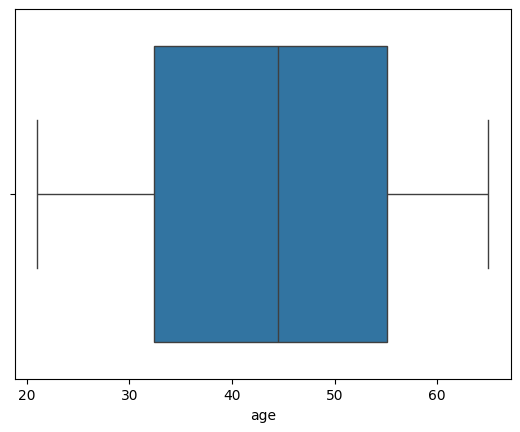

In [13]:
sns.boxplot(
    x=df["age"]
)

plt.show()

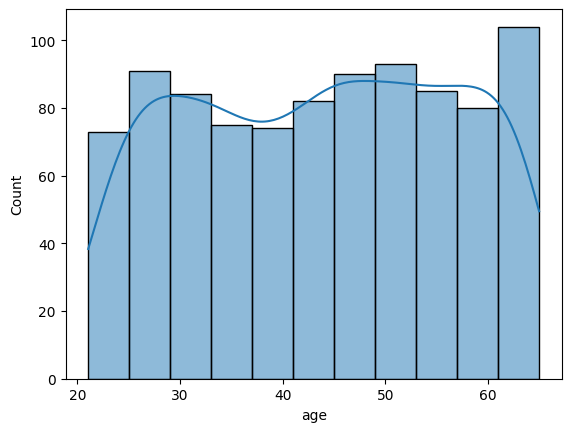

In [14]:
sns.histplot(
    df["age"],
    kde=True
)

plt.show()

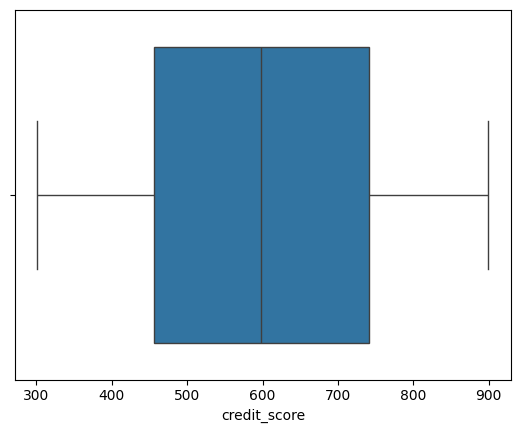

In [15]:
sns.boxplot(
    x=df['credit_score']
)

plt.show()

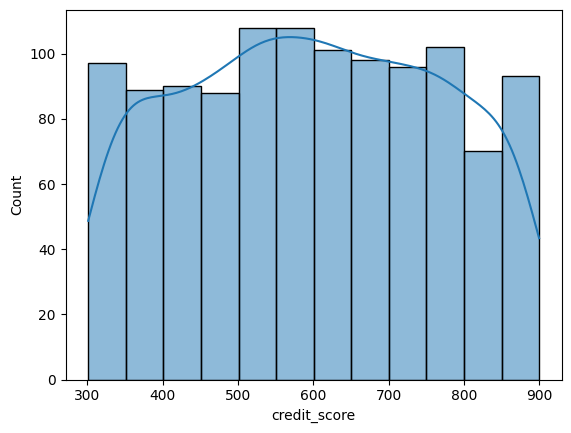

In [16]:
sns.histplot(
    df['credit_score'],
    kde=True
)

plt.show()

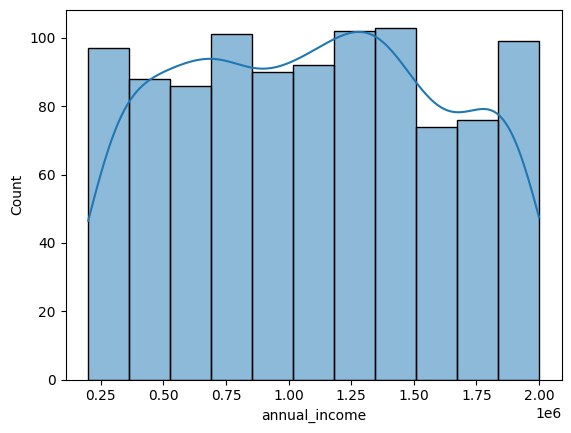

In [17]:
sns.histplot(
    df["annual_income"], 
    kde=True
)

plt.show()

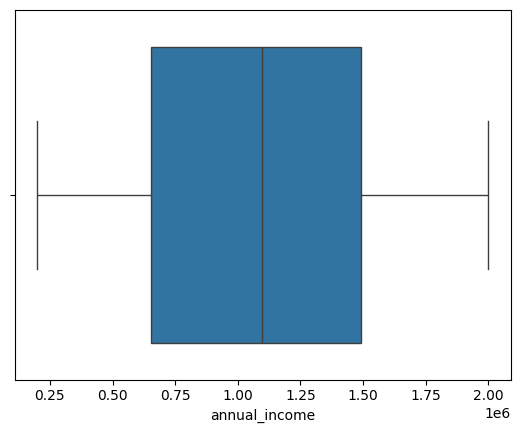

In [18]:
sns.boxplot(
    x=df["annual_income"]
)

plt.show()

In [19]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 employment_type
employment_type
Self-Employed    411
Business         395
Salaried         389
NaN              205
Name: count, dtype: int64

 education_level
education_level
NaN              400
Graduate         257
Post-Graduate    252
Diploma          246
PhD              245
Name: count, dtype: int64

 marital_status
marital_status
Married     381
Divorced    379
Single      372
NaN         268
Name: count, dtype: int64

 property_owned
property_owned
No     607
Yes    588
NaN    205
Name: count, dtype: int64

 loan_purpose
loan_purpose
Personal     296
Home         294
Education    284
Car          281
NaN          245
Name: count, dtype: int64

 default
default
Yes    536
No     511
NaN    353
Name: count, dtype: int64


#### 3. Filling the missing values

In [24]:
dfcopy = df.copy()

In [26]:
dfcopy.head(10)

,age,annual_income,loan_amount,credit_score,loan_tenure_years,existing_loans,employment_type,education_level,marital_status,property_owned,loan_purpose,default
0,50.580257,3.305169e+05,NaN,599.115566,7.682099,NaN,Self-Employed,PhD,NaN,No,Home,No
1,42.475450,1.399313e+06,7.405586e+05,784.022640,NaN,1.322204,Salaried,Diploma,Divorced,Yes,Personal,Yes
2,57.321788,5.759531e+05,4.686859e+05,448.876010,29.579995,NaN,Salaried,PhD,NaN,Yes,Personal,Yes
3,NaN,NaN,1.052662e+06,733.207406,13.870311,4.415269,Self-Employed,Diploma,Married,Yes,NaN,NaN
4,56.554198,NaN,3.833395e+05,302.874446,29.993313,4.245685,NaN,Diploma,Married,No,Car,No
5,NaN,1.645173e+06,1.384928e+06,576.588094,16.754956,NaN,Business,PhD,Single,Yes,Personal,Yes
6,34.095390,NaN,1.317535e+06,846.916580,24.197019,1.416404,Salaried,PhD,Divorced,No,Personal,No
7,NaN,NaN,1.077513e+06,381.995917,16.971989,4.760454,Salaried,NaN,Married,Yes,NaN,Yes
8,NaN,2.851000e+05,9.543281e+05,807.293290,23.767143,3.969454,Self-Employed,Diploma,Divorced,Yes,Car,No
9,NaN,1.806723e+06,4.304563e+05,568.293704,26.331020,1.525403,Self-Employed,Diploma,Divorced,Yes,NaN,NaN


Using mean to fill the missing values for numerical columns.

In [27]:
num_cols = dfcopy.select_dtypes(include="number").columns

for col in num_cols:
    dfcopy[col] = dfcopy[col].fillna(dfcopy[col].mean())

In [28]:
dfcopy.isnull().sum()

age                    0
annual_income          0
loan_amount            0
credit_score           0
loan_tenure_years      0
existing_loans         0
employment_type      205
education_level      400
marital_status       268
property_owned       205
loan_purpose         245
default              353
dtype: int64

In [29]:
cat_cols = dfcopy.select_dtypes(include="object").columns

for col in cat_cols:
    dfcopy[col] = dfcopy[col].fillna("Unknown")

In [30]:
dfcopy.isnull().sum()

age                  0
annual_income        0
loan_amount          0
credit_score         0
loan_tenure_years    0
existing_loans       0
employment_type      0
education_level      0
marital_status       0
property_owned       0
loan_purpose         0
default              0
dtype: int64

#### 4. Outlier Analysis

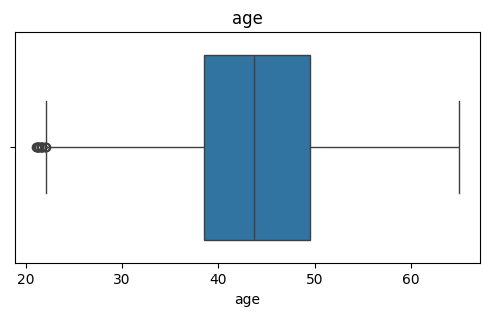

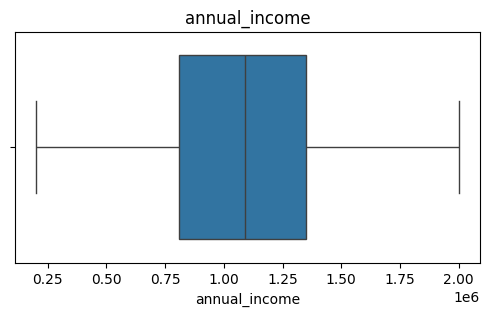

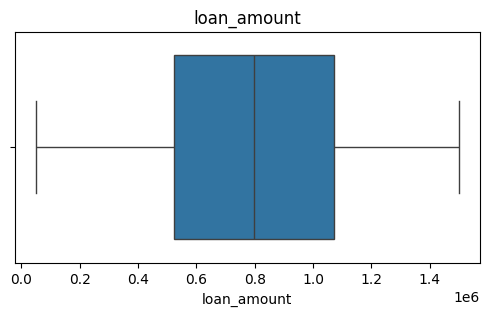

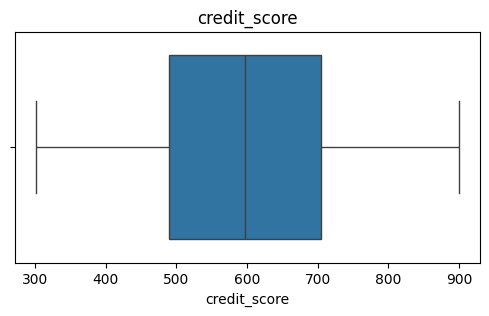

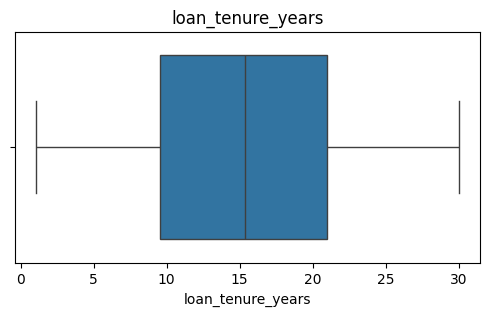

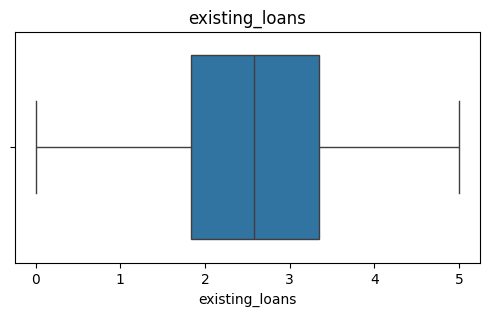

In [31]:
num_cols = dfcopy.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=dfcopy[col])
    plt.title(col)
    plt.show()

In [32]:
dfcopy["age"].describe()

count    1400.000000
mean       43.741215
std        10.444651
min        21.058600
25%        38.521966
50%        43.741215
75%        49.502529
max        64.970306
Name: age, dtype: float64

#### 5. Univariate analysis

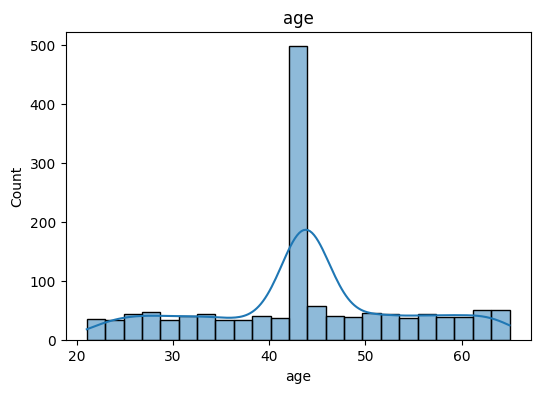

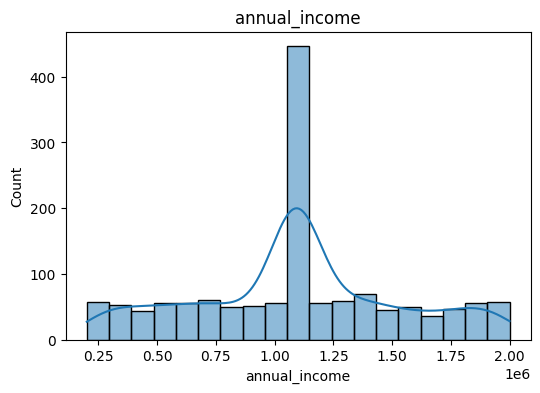

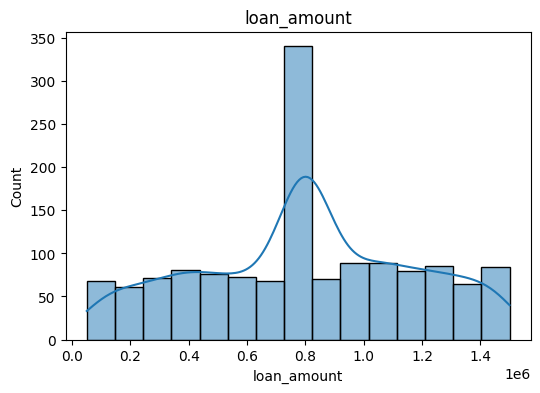

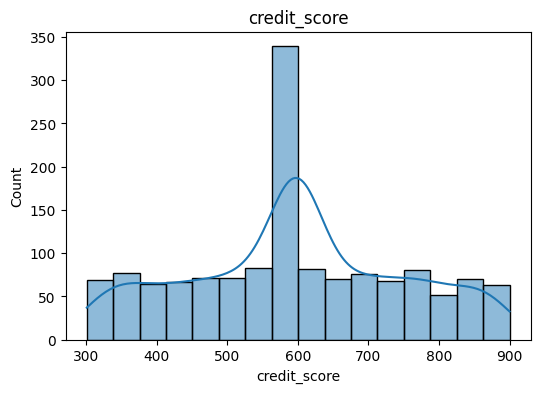

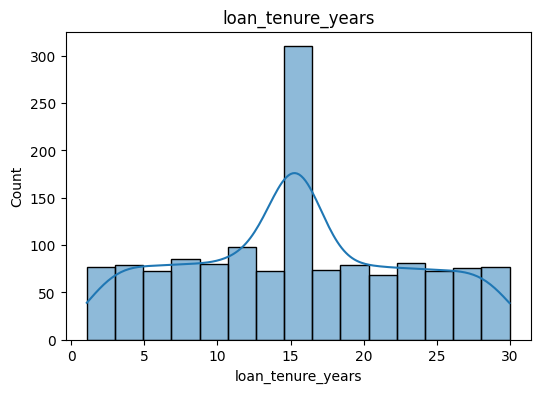

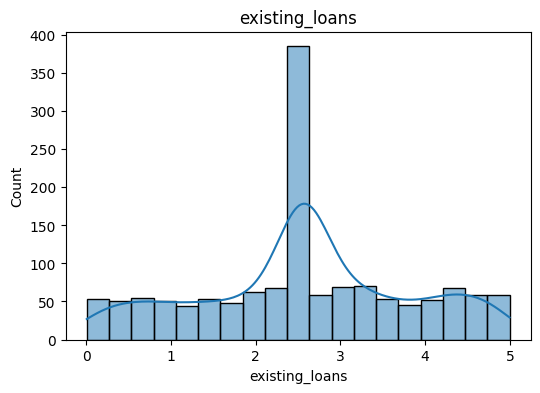

In [35]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(dfcopy[col], kde=True)
    plt.title(col)
    plt.show()

In [36]:
for col in cat_cols:
    print("\n", col)
    print(dfcopy[col].value_counts())


 employment_type
employment_type
Self-Employed    411
Business         395
Salaried         389
Unknown          205
Name: count, dtype: int64

 education_level
education_level
Unknown          400
Graduate         257
Post-Graduate    252
Diploma          246
PhD              245
Name: count, dtype: int64

 marital_status
marital_status
Married     381
Divorced    379
Single      372
Unknown     268
Name: count, dtype: int64

 property_owned
property_owned
No         607
Yes        588
Unknown    205
Name: count, dtype: int64

 loan_purpose
loan_purpose
Personal     296
Home         294
Education    284
Car          281
Unknown      245
Name: count, dtype: int64

 default
default
Yes        536
No         511
Unknown    353
Name: count, dtype: int64


#### 6. Bivariate analysis

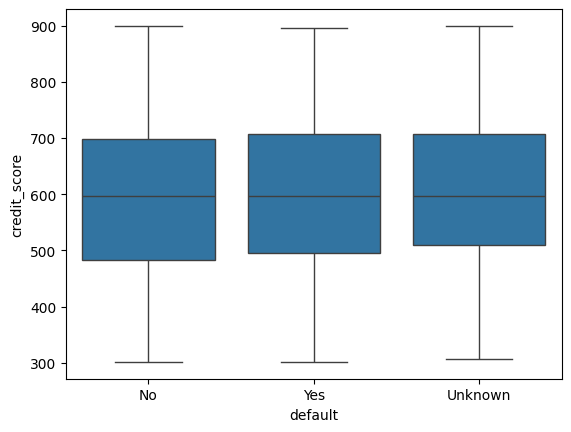

In [38]:
sns.boxplot(
    x="default",
    y="credit_score",
    data=dfcopy
)

plt.show()

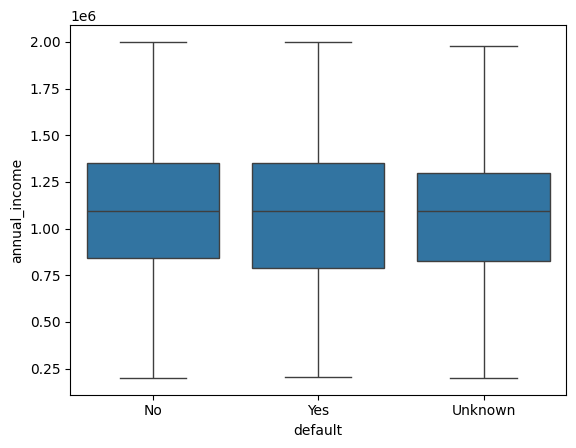

In [39]:
sns.boxplot(
    x="default",
    y="annual_income",
    data=dfcopy
)

plt.show()

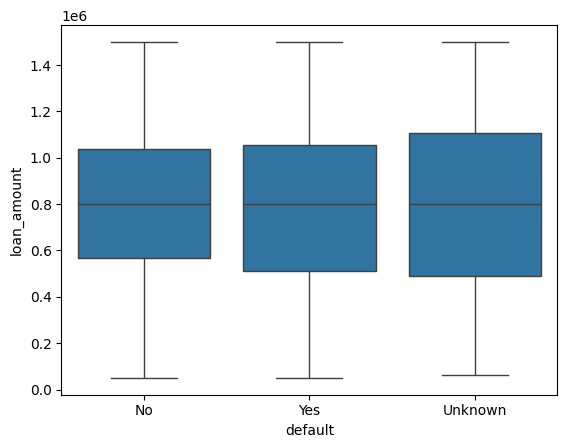

In [40]:
sns.boxplot(
    x="default",
    y="loan_amount",
    data=dfcopy
)

plt.show()

In [41]:
pd.crosstab(
    dfcopy["employment_type"],
    dfcopy["default"],
    normalize="index"
) * 100

default,No,Unknown,Yes
employment_type,,,
Business,35.696203,25.569620,38.734177
Salaried,34.961440,24.421594,40.616967
Self-Employed,38.929440,25.547445,35.523114
Unknown,36.097561,25.365854,38.536585


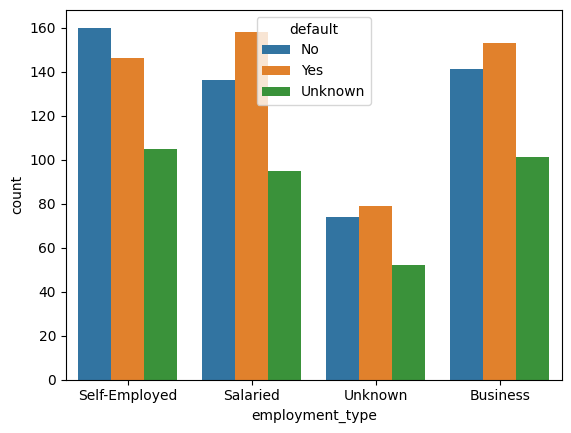

In [42]:
sns.countplot(
    x = "employment_type",
    hue="default",
    data=dfcopy
)

plt.show()

In [ ]:
pd.crosstab(
    dfcopy["loan_purpose"],
    dfcopy["default"],
    normalize="index"
) * 100

default,No,Yes
loan_purpose,,
Car,50.980392,49.019608
Education,54.929577,45.070423
Home,44.843049,55.156951
Personal,50.000000,50.000000


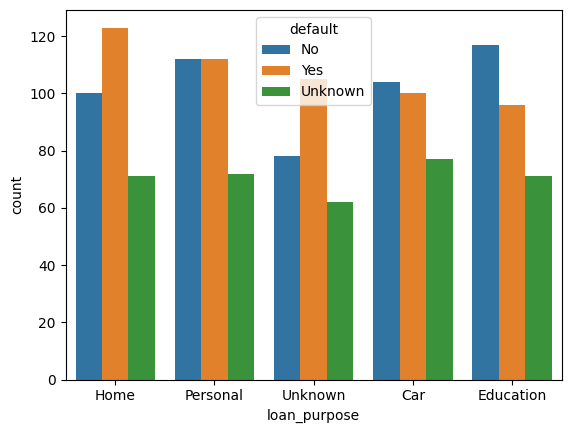

In [44]:
sns.countplot(
    x = "loan_purpose",
    hue="default",
    data=dfcopy
)

plt.show()

In [45]:
pd.crosstab(
    dfcopy["property_owned"],
    dfcopy["default"],
    normalize="index"
) * 100

default,No,Unknown,Yes
property_owned,,,
No,36.573311,25.041186,38.385502
Unknown,30.243902,29.268293,40.487805
Yes,38.605442,23.979592,37.414966


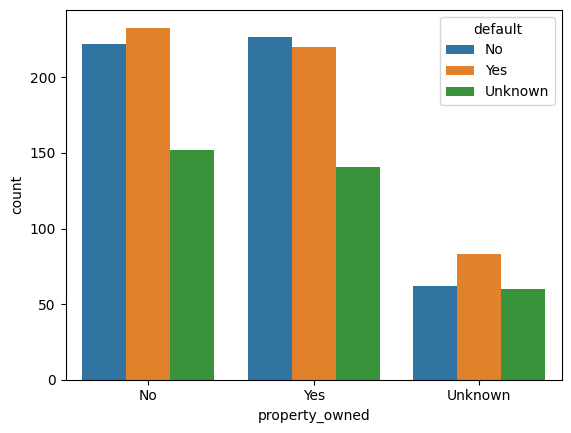

In [46]:
sns.countplot(
    x = "property_owned",
    hue="default",
    data=dfcopy
)

plt.show()

In [47]:
pd.crosstab(
    dfcopy["marital_status"],
    dfcopy["default"],
    normalize="index"
) * 100

default,No,Unknown,Yes
marital_status,,,
Divorced,36.675462,25.857520,37.467018
Married,37.532808,27.821522,34.645669
Single,33.333333,25.268817,41.397849
Unknown,39.179104,20.522388,40.298507


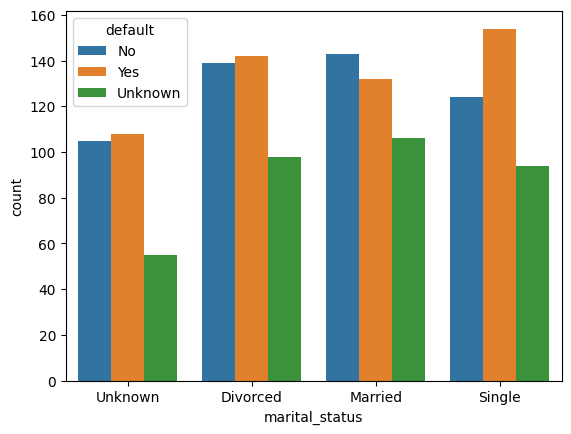

In [48]:
sns.countplot(
    x = "marital_status",
    hue="default",
    data=dfcopy
)

plt.show()

In [49]:
pd.crosstab(
    dfcopy["property_owned"],
    dfcopy["default"],
    normalize="index"
) * 100

default,No,Unknown,Yes
property_owned,,,
No,36.573311,25.041186,38.385502
Unknown,30.243902,29.268293,40.487805
Yes,38.605442,23.979592,37.414966


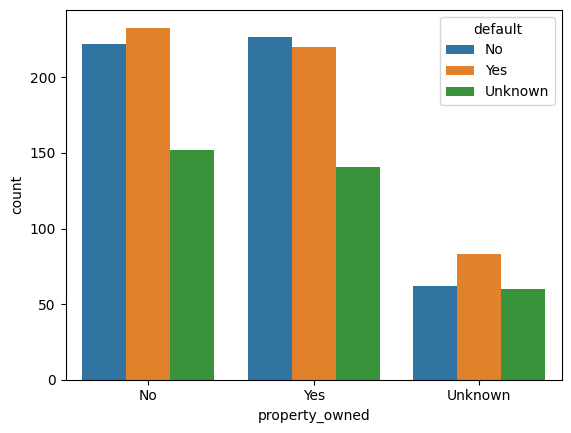

In [50]:
sns.countplot(
    x = "property_owned",
    hue="default",
    data=dfcopy
)

plt.show()

#### 7. Correlation analysis

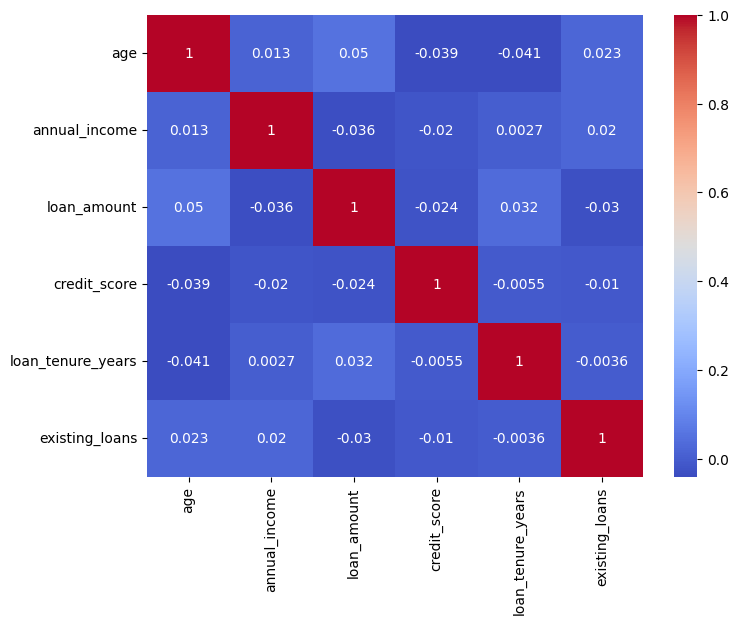

In [51]:
corr = dfcopy.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### 8. Multivariate analysis

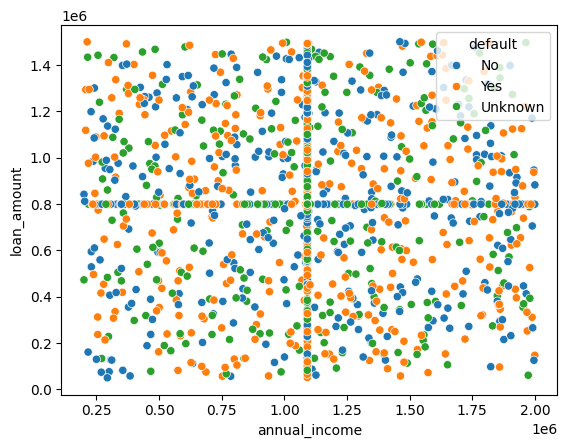

In [52]:
sns.scatterplot(
    data=dfcopy,
    x="annual_income",
    y="loan_amount",
    hue="default"
)
plt.show()

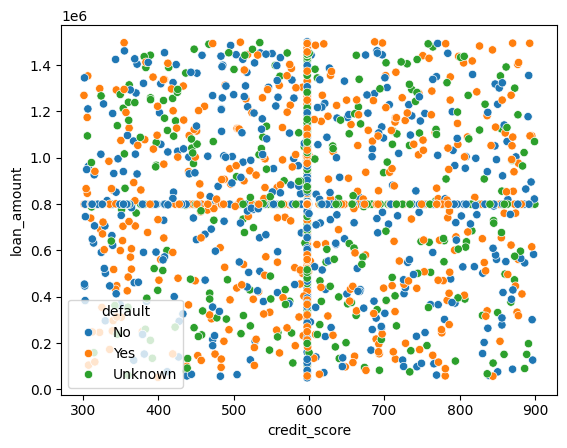

In [53]:
sns.scatterplot(
    data=dfcopy,
    x="credit_score",
    y="loan_amount",
    hue="default"
)
plt.show()

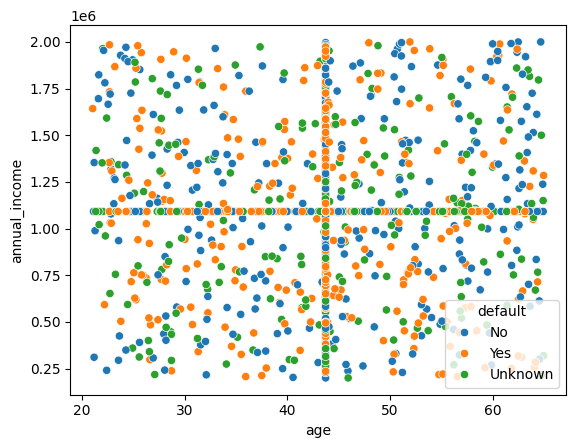

In [54]:
sns.scatterplot(
    data=dfcopy,
    x="age",
    y="annual_income",
    hue="default"
)
plt.show()

# Loan Default Dataset - Exploratory Data Analysis (EDA) Report

# 1. Dataset Overview

## Dataset Description

The dataset contains borrower information, loan details, financial characteristics, and loan default status.

### Numerical Variables

* Age
* Annual Income
* Loan Amount
* Credit Score
* Loan Tenure Years
* Existing Loans

### Categorical Variables

* Employment Type
* Education Level
* Marital Status
* Property Owned
* Loan Purpose
* Default

### Target Variable

```text
Default
```

The dataset appears to be designed for predicting whether a borrower will default on a loan.

---

# 2. Initial Data Quality Assessment

## Missing Values

Missing values were present in all columns.

### Numerical Columns

* Age
* Annual Income
* Loan Amount
* Credit Score
* Loan Tenure Years
* Existing Loans

### Categorical Columns

* Employment Type
* Education Level
* Marital Status
* Property Owned
* Loan Purpose
* Default

---

## Duplicate Records

No duplicate records were identified in the dataset.

---

## Data Quality Observations

### Existing Loans

The Existing Loans column contained continuous decimal values ranging from approximately:

```text
0.004669
to
4.996362
```

Since loan counts are typically whole numbers, this likely indicates synthetic data generation rather than actual loan counts.

The values were retained during EDA and documented as a dataset characteristic.

---

# 3. Missing Value Treatment

## Numerical Variables

### Observations

* Distributions were generally balanced.
* No major skewness was observed.
* No significant outliers were present.
* Most boxplots exhibited centered medians.

### Imputation Strategy

```text
Mean Imputation
```

was applied to all numerical variables.

### Reasoning

Mean imputation was chosen because:

* Distributions were relatively symmetric.
* Outliers were minimal or absent.
* Mean values represented the overall distribution effectively.

---

## Categorical Variables

### Observations

* No categorical column had a dominant category.
* Missing values represented a significant portion of several columns.
* Education contained particularly large numbers of missing values.

### Imputation Strategy

```text
Unknown
```

was introduced as a separate category.

### Reasoning

Using mode imputation would artificially inflate existing categories and distort the original distribution.

Creating an Unknown category preserves information regarding missingness while maintaining category balance.

---

# 4. Outlier Analysis

## Method Used

---

## Findings

### Age

The Age variable displayed a small number of lower-end outliers.

#### Statistics

```text
Minimum Age = 21.06
Q1 = 38.52
Median = 43.74
Q3 = 49.50
Maximum Age = 64.97
```

### Interpretation

Although identified as outliers by the IQR method, the values represent realistic borrower ages.

### Decision

```text
Retained
```

The observations are valid and may contain meaningful information regarding borrower behavior.

---

### Remaining Numerical Variables

* Annual Income
* Loan Amount
* Credit Score
* Loan Tenure Years
* Existing Loans

No significant outliers were identified.

---

# 5. Univariate Analysis

## Numerical Variables

### Common Value Ranges

#### Age

Most borrowers were concentrated in older age ranges, particularly near 60 years and above.

#### Annual Income

Most observations were concentrated between:

```text
1.25M – 1.50M
```

#### Loan Amount

Most loans were concentrated around:

```text
1.00M – 1.15M
```

#### Credit Score

Most observations were concentrated between:

```text
500 – 600
```

#### Loan Tenure

Most borrowers had loan tenures between:

```text
11 – 14 years
```

#### Existing Loans

Most observations were concentrated around:

```text
3 loans
```

---

## Categorical Variables

### Employment Type

Most common category:

```text
Self-Employed
```

### Marital Status

Most common category:

```text
Married
```

### Education Level

The Unknown category became dominant due to the large number of missing values.

### Default

Distribution:

```text
Yes     = 536
No      = 511
Unknown = 353
```

The target variable remains relatively balanced.

---

# 6. Bivariate Analysis

## 6.1 Numerical Variables vs Default

Boxplots were generated for:

* Age vs Default
* Annual Income vs Default
* Loan Amount vs Default
* Credit Score vs Default
* Loan Tenure vs Default
* Existing Loans vs Default

### Findings

Across all variables:

* Median values were nearly identical.
* Distributions heavily overlapped.
* No meaningful separation between default categories was observed.

### Conclusion

Numerical variables individually exhibit weak relationships with loan default.

---

## 6.2 Employment Type vs Default

### Findings

The largest difference was observed within Salaried borrowers.

```text
No  ≈ 40.61%
Yes ≈ 34.96%
```

Difference:

```text
≈ 5.65%
```

### Conclusion

Employment Type exhibits a weak relationship with default.

---

## 6.3 Marital Status vs Default

### Findings

Single borrowers showed the largest variation.

```text
No  ≈ 33.33%
Yes ≈ 41.40%
```

Difference:

```text
≈ 8%
```

### Conclusion

Marital Status exhibits a moderate relationship with default.

---

## 6.4 Property Owned vs Default

### Findings

No noticeable differences were observed between categories.

### Conclusion

Property ownership does not appear strongly associated with default.

---

## 6.5 Loan Purpose vs Default

### Findings

Loan Purpose displayed the strongest relationship with default.

#### Education Loans

```text
No  = 54.93%
Yes = 45.07%
```

#### Home Loans

```text
No  = 44.84%
Yes = 55.16%
```

Difference:

```text
≈ 10%
```

### Conclusion

Loan Purpose is the strongest categorical predictor identified during EDA.

---

# 7. Correlation Analysis

## Method

Pearson Correlation Matrix and Heatmap

---

## Highest Positive Correlation

```text
Age ↔ Loan Amount = 0.05
```

---

## Second Highest Positive Correlation

```text
Annual Income ↔ Existing Loans = 0.02
```

---

## Highest Negative Correlation

```text
Age ↔ Loan Tenure = -0.041
```

---

## Second Highest Negative Correlation

```text
Age ↔ Credit Score = -0.039
```

---

## Interpretation

All observed correlations fall within:

```text
-0.05 to 0.05
```

which indicates negligible relationships.

### Conclusion

No meaningful linear relationships exist among numerical variables.

---

# 8. Multivariate Analysis

## Analysis Performed

Scatterplots were generated for:

### Annual Income vs Loan Amount

Colored by:

```text
Default
```

### Credit Score vs Loan Amount

Colored by:

```text
Default
```

### Age vs Annual Income

Colored by:

```text
Default
```

---

## Findings

All three plots displayed:

* Heavy overlap between categories.
* No visible clusters.
* No meaningful separation.
* Large central "+" shaped concentration.

### Explanation of "+" Pattern

The central concentration was caused by mean imputation.

Rows containing missing values were assigned identical mean values, creating horizontal and vertical concentrations in scatterplots.

---

## Conclusion

Combinations of numerical variables do not clearly explain or separate loan default behavior.

---

# 9. Key Findings

## Strongest Relationships

### Loan Purpose

Most significant relationship observed.

```text
Home Loans → Higher Default %
Education Loans → Lower Default %
```

---

### Marital Status

Single borrowers showed moderately higher default percentages.

---

### Employment Type

Minor differences observed.

---

## Weak Relationships

The following variables showed little or no ability to distinguish default categories:

* Age
* Annual Income
* Loan Amount
* Credit Score
* Loan Tenure
* Existing Loans
* Property Owned

---

# 10. Final Conclusion

The loan default dataset exhibits extremely weak numerical relationships and negligible correlations among numerical variables.

Most numerical variables showed substantial overlap across default categories and provided little evidence of predictive power during visual analysis.

Among categorical variables, Loan Purpose emerged as the strongest indicator of default behavior, followed by Marital Status and Employment Type.